# Synoptic Composites — Sampled Events
**Author:** Michael Wasserstein  
**Created:** 10/25/2024  

Produces three-panel composite plots (S/SWIVT, Frontal, NW Post-Frontal) showing mean
500-hPa geopotential height, 700-hPa temperature/winds, and IVT for sampled LCC events at the mid time (hr 6) in the 12 hr events of interest.

## Imports and configuration

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import glob
import metpy.calc as mpcalc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

# Physical constants
g = 9.80665  # m s^-2

# Classification lookup
classification_dict = {
    0: 'NA',
    1: 'SIVT',
    2: 'SWIVT',
    3: 'WIVT',
    4: 'NWIVT',
    5: 'NWPF',
    6: 'FR',
    7: 'SWCC',
    8: 'CL',
}

# ── User-configurable parameters ────────────────────────────────────────────
percentile = 75
region     = 'IM'

# ERA5 data roots
base_path_iso = '/path/to/era5/iso/data/'
base_path_sfc = '/path/to/era5/sfc/data/'

# Storm classification CSV directory
# Expected files: CLN_2023_Events_precip_75.csv, CLN_2023_Events_snow_75.csv, etc.
dir_75 = 'Data/'


ERROR 1: PROJ: proj_create_from_database: Open of /uufs/chpc.utah.edu/common/home/u1371671/software/pkg/miniconda3/envs/Radar_env_2/share/proj failed


## Helper functions

In [ ]:
def ivt_fill_colors():
    """Return ordered list of hex colors for IVT filled contours."""
    return [
        '#3488c4', '#68bca8', '#b6ec8c', '#ebf15e', '#dfae31',
        '#d06932', '#be2b32', '#950002', '#750546', '#45062b',
    ]


def synoptic_regions():
    """Return bounding-box dictionary (W, E, S, N) for standard synoptic domains."""
    return {
        'WS': (-129, -101, 30, 50),
        'WE': (-140, -104, 30, 50),
        'IM': (-125, -101, 30, 50),
    }


def is_in_time_ranges(row, time_ranges, start_col='start_time_UTC', end_col='end_time_UTC'):
    """Return True if the event [start, end] overlaps any interval in *time_ranges*."""
    return any((row[start_col] < end) and (row[end_col] > start) for start, end in time_ranges)


def load_composite_data(dataset, combined_df,
                        base_path_iso, base_path_sfc,
                        lat_slice, lon_slice, lev_slice, g=9.80665):
    """
    Load and process ERA5 isobaric + surface data for a set of events.

    Parameters
    ----------
    dataset : pd.DataFrame
        Event DataFrame that must contain a 'mid_time_UTC' column.
    combined_df : pd.DataFrame
        Master event DataFrame with '12_hr_LPE_mm' and '12_hr_snow_cm' columns.
    base_path_iso, base_path_sfc : str
        Root paths for ERA5 isobaric and surface archives.
    lat_slice, lon_slice, lev_slice : slice
        Spatial and vertical subsetting slices.
    g : float
        Gravitational acceleration (m s^-2).

    Returns
    -------
    dict with keys:
        'IVT'        - np.ndarray (time, lat, lon)
        'hght_500'   - np.ndarray (time, lat, lon), geopotential height [m]
        'u_700'      - np.ndarray (time, lat, lon), wind [kt]
        'v_700'      - np.ndarray (time, lat, lon), wind [kt]
        't_700'      - np.ndarray (time, lat, lon), temperature [°C]
        'lons'       - 2-D np.ndarray, longitude grid
        'lats'       - 2-D np.ndarray, latitude grid
        'mean_LPE'   - float, mean 12-hr LPE [mm]
        'mean_snow'  - float, mean 12-hr snow depth [cm]
    """
    times = dataset['mid_time_UTC'].values

    # ── Collect file paths ───────────────────────────────────────────────────
    iso_files = []
    sfc_files = []

    # Variable formats
    iso_vars = {'_u.ll025', '_v.ll025', '_q.ll025', '_z.ll025', '_t.ll025'}
    sfc_vars = {'_2d.ll025', '_10v.ll025', '_10u.ll025', '_sp.ll025'}

    # Loop through all the event times and extract the data files
    for event_mid_time in times:
        t = pd.to_datetime(event_mid_time)
        YYYY, mm, DD = t.year, t.month, t.day

        iso_path = base_path_iso + f'{YYYY}{mm:02}/'
        sfc_path = base_path_sfc + f'{YYYY}{mm:02}/'

        pattern = f'*{YYYY}{mm:02}{DD:02}23.WE.nc'
        iso_files += [f for f in glob.glob(iso_path + pattern)
                      if any(v in f for v in iso_vars)]
        sfc_files += [f for f in glob.glob(sfc_path + pattern)
                      if any(v in f for v in sfc_vars)]

    # Get all the unique data files
    iso_files = list(set(iso_files))
    sfc_files = sorted(set(sfc_files))

    # ── Load isobaric data ───────────────────────────────────────────────────
    iso_data = xr.open_mfdataset(iso_files)
    iso_data = (iso_data
                .assign_coords(longitude=(((iso_data.longitude + 180) % 360) - 180))
                .sortby('longitude').sortby('latitude'))

    # ── Load surface data (handle ERA5 format quirks) ────────────────────────
    # Occationally the files will have "valid_time" or "expver", which you don't want
    datasets_sp, datasets_10u, datasets_10v, datasets_2d = [], [], [], []

    # Loop through files
    for file in sfc_files:
        ds = xr.open_dataset(file)
        if 'valid_time' in ds.dims:
            ds = ds.rename_dims({'valid_time': 'time'}).rename({'valid_time': 'time'})
        if 'expver' in ds.coords:
            ds = ds.drop_vars(['expver', 'number'])

        # Get varibale so interest
        if 'sp'  in ds.data_vars: datasets_sp.append(ds)
        if 'u10' in ds.data_vars: datasets_10u.append(ds)
        if 'v10' in ds.data_vars: datasets_10v.append(ds)
        if 'd2m' in ds.data_vars: datasets_2d.append(ds)

    # Produce one dataset
    sfc_data = xr.merge([
        xr.concat(datasets_sp,  dim='time'),
        xr.concat(datasets_10u, dim='time'),
        xr.concat(datasets_10v, dim='time'),
        xr.concat(datasets_2d,  dim='time'),
    ])
    sfc_data = (sfc_data
                .assign_coords(longitude=(((sfc_data.longitude + 180) % 360) - 180))
                .sortby('longitude').sortby('latitude'))

    # ── Subset to domain and selected times ──────────────────────────────────
    times_64 = times.astype('datetime64')
    iso_data = iso_data.sel(level=lev_slice, longitude=lon_slice,
                            latitude=lat_slice, time=times_64)
    sfc_data = sfc_data.sel(latitude=lat_slice, longitude=lon_slice, time=times_64)
    iso_data = xr.merge([iso_data, sfc_data])

    # ── IVT: pressure-level component ────────────────────────────────────────
    nt, nz, ny, nx = (len(iso_data.time), len(iso_data.level),
                      len(iso_data.latitude), len(iso_data.longitude))
    iso_data['uxq'] = (('time', 'level', 'latitude', 'longitude'), np.zeros((nt, nz, ny, nx)))
    iso_data['vxq'] = (('time', 'level', 'latitude', 'longitude'), np.zeros((nt, nz, ny, nx)))

    for count, level_ in enumerate(iso_data.level.values):
        above = iso_data.sp * 0.01 > level_ # make sure you are above the surface
        iso_data.uxq[:, count] = (iso_data.u.sel(level=level_).where(above, other=0)
                                  * iso_data.q.sel(level=level_).where(above, other=0))
        iso_data.vxq[:, count] = (iso_data.v.sel(level=level_).where(above, other=0)
                                  * iso_data.q.sel(level=level_).where(above, other=0))

    # Compute IVT
    iso_data['uivt'] = -iso_data.uxq.integrate('level') * 100 / g
    iso_data['vivt'] = -iso_data.vxq.integrate('level') * 100 / g
    iso_data['ivt']  = np.sqrt(iso_data['uivt'] ** 2 + iso_data['vivt'] ** 2)

    # ── IVT: surface-to-lowest-level correction ───────────────────────────────
    # This code calculates the ivt from between the surface and the lowest
    # ERA5 level
    sfcq = mpcalc.specific_humidity_from_dewpoint(iso_data.sp, iso_data.d2m)
    iso_data['sfcuxq'] = iso_data.u10 * sfcq
    iso_data['sfcvxq'] = iso_data.v10 * sfcq

    iso_data['lowestp'] = (('time', 'latitude', 'longitude'),
                           np.zeros((nt, ny, nx)))
    for count, level in enumerate(iso_data.level.values):
        if count == 0:
            iso_data['lowestp'][:] = level
        else:
            iso_data['lowestp'] = iso_data.lowestp.where(
                iso_data.sp * 0.01 <= level, other=level)

    lowestp_uxq = iso_data.uxq.where(iso_data.level == iso_data.lowestp).max(axis=1)
    lowestp_vxq = iso_data.vxq.where(iso_data.level == iso_data.lowestp).max(axis=1)

    dp = iso_data.sp - iso_data['lowestp'] * 100
    sfcluivt = 0.5 * (iso_data['sfcuxq'] + lowestp_uxq) * dp / g
    sfclvivt = 0.5 * (iso_data['sfcvxq'] + lowestp_vxq) * dp / g
    iso_data['ivt'] = iso_data['ivt'] + np.sqrt(sfcluivt ** 2 + sfclvivt ** 2)

    # ── Extract and smooth output arrays ─────────────────────────────────────
    IVT      = iso_data.ivt.values
    hght_500 = gaussian_filter(iso_data.z.sel(level=500).values / g, sigma=2.0)
    u_700    = gaussian_filter(iso_data.u.sel(level=700).values, sigma=2.0) * 1.94
    v_700    = gaussian_filter(iso_data.v.sel(level=700).values, sigma=2.0) * 1.94
    t_700    = gaussian_filter(iso_data.t.sel(level=700).values, sigma=2.0) - 273.15

    lon1d = iso_data.longitude.values
    lat1d = iso_data.latitude.values
    lons, lats = np.meshgrid(lon1d, lat1d)

    mean_LPE  = round(combined_df.loc[combined_df['mid_time_UTC'].isin(times),
                                       '12_hr_LPE_mm'].mean(), 2)
    mean_snow = round(combined_df.loc[combined_df['mid_time_UTC'].isin(times),
                                       '12_hr_snow_cm'].mean(), 2)

    return dict(IVT=IVT, hght_500=hght_500,
                u_700=u_700, v_700=v_700, t_700=t_700,
                lons=lons, lats=lats,
                mean_LPE=mean_LPE, mean_snow=mean_snow)

## Load event classifications

In [ ]:
# Columns from dataset that aren't needed
drop_cols_precip = ['Comments', 'Objective_Classification', 'Unnamed: 0']
drop_cols_snow   = ['Comments', 'Objective_Classification', 'Unnamed: 11', 'Unnamed: 0']

# Precip dataset
precip_75 = pd.concat([
    pd.read_csv(dir_75 + f'CLN_2023_Events_precip_{percentile}.csv'),
    pd.read_csv(dir_75 + f'CLN_2024_Events_precip_{percentile}.csv'),
]).drop(columns=drop_cols_precip).reset_index(drop=True)

# Snow dataset
snow_75 = pd.concat([
    pd.read_csv(dir_75 + f'CLN_2023_Events_snow_{percentile}.csv'),
    pd.read_csv(dir_75 + f'CLN_2024_Events_snow_{percentile}.csv'),
]).drop(columns=drop_cols_snow).reset_index(drop=True)

# Merge snow + precip, deduplicate, sort, and drop two bad
combined_df = (
    pd.concat([snow_75, precip_75], ignore_index=True)
    .drop_duplicates()
    .reset_index(drop=True)
)
combined_df['Time (LST)'] = pd.to_datetime(combined_df['Time (LST)'])
combined_df = combined_df.sort_values('Time (LST)').reset_index(drop=True)
combined_df = combined_df.drop(index=[12, 58]).reset_index(drop=True)  # bad events

combined_df['start_time_UTC'] = pd.to_datetime(combined_df['start_time_UTC'])
combined_df['end_time_UTC']   = pd.to_datetime(combined_df['end_time_UTC'])


## Define sampled event time ranges and filter events

Each tuple is a (start, end) UTC timestamp for a 12-h observing window. `title_header` describes the event type and is used in the output filename. These were manually classified before analysis, following methods from [Wasserstein and Steenburgh (2024)](https://journals.ametsoc.org/view/journals/mwre/152/4/MWR-D-23-0206.1.xml).

In [4]:
def to_utc_dt(pairs):
    """Convert list of (start_str, end_str) to tz-aware UTC datetime tuples."""
    return [(pd.to_datetime(s).tz_localize('UTC'),
             pd.to_datetime(e).tz_localize('UTC')) for s, e in pairs]


# S/SWIVT events with data available at both sites
sivt_dt = to_utc_dt([
    ('2022-12-01 23:00', '2022-12-02 11:00'),
    ('2022-12-11 23:00', '2022-12-12 11:00'),
    ('2022-12-31 23:00', '2023-01-01 11:00'),
    ('2023-01-01 11:00', '2023-01-01 23:00'),
    ('2023-01-09 23:00', '2023-01-10 11:00'),
    ('2023-01-14 23:00', '2023-01-15 11:00'),
    ('2023-03-14 22:00', '2023-03-15 10:00'),
    ('2024-02-01 23:00', '2024-02-02 11:00'),
    ('2024-02-05 11:00', '2024-02-05 23:00'),
    ('2024-02-06 23:00', '2024-02-07 11:00'),
    ('2024-02-19 23:00', '2024-02-20 11:00'),
    ('2024-03-28 10:00', '2024-03-28 22:00'),
    ('2024-03-30 22:00', '2024-03-31 10:00'),
])

# Frontal events with data available at both sites
fr_dt = to_utc_dt([
    ('2022-12-04 23:00', '2022-12-05 11:00'),
    ('2022-12-27 23:00', '2022-12-28 11:00'),
    ('2023-01-10 23:00', '2023-01-11 11:00'),
    ('2023-02-05 11:00', '2023-02-05 23:00'),
    ('2023-02-21 23:00', '2023-02-22 11:00'),
    ('2023-03-05 23:00', '2023-03-06 11:00'),
    ('2023-03-10 23:00', '2023-03-11 11:00'),
    ('2023-03-15 10:00', '2023-03-15 22:00'),
    ('2023-03-24 10:00', '2023-03-24 22:00'),
    ('2024-02-15 11:00', '2024-02-15 23:00'),
    ('2024-02-26 23:00', '2024-02-27 11:00'),
    ('2024-03-23 22:00', '2024-03-24 10:00'),
])

# NW Post-Frontal events with data available at both sites
pf_dt = to_utc_dt([
    ('2022-11-28 23:00', '2022-11-29 11:00'),
    ('2022-12-12 23:00', '2022-12-13 11:00'),
    ('2022-12-13 11:00', '2022-12-13 23:00'),
    ('2022-12-13 23:00', '2022-12-14 11:00'),
    ('2022-12-14 11:00', '2022-12-14 23:00'),
    ('2022-12-15 11:00', '2022-12-15 23:00'),
    ('2022-12-28 11:00', '2022-12-28 23:00'),
    ('2022-12-28 23:00', '2022-12-29 11:00'),
    ('2023-01-06 11:00', '2023-01-06 23:00'),
    ('2023-01-11 11:00', '2023-01-11 23:00'),
    ('2023-01-24 23:00', '2023-01-25 11:00'),
    ('2023-01-27 23:00', '2023-01-28 11:00'),
    ('2023-01-28 11:00', '2023-01-28 23:00'),
    ('2023-02-06 11:00', '2023-02-06 23:00'),
    ('2023-03-24 22:00', '2023-03-25 10:00'),
    ('2023-03-27 10:00', '2023-03-27 22:00'),
    ('2023-12-08 11:00', '2023-12-08 23:00'),
    ('2023-12-08 23:00', '2023-12-09 11:00'),
    ('2024-01-05 11:00', '2024-01-05 23:00'),
    ('2024-01-07 11:00', '2024-01-07 23:00'),
    ('2024-01-14 11:00', '2024-01-14 23:00'),
    ('2024-02-02 23:00', '2024-02-03 11:00'),
    ('2024-02-03 23:00', '2024-02-04 11:00'),
    ('2024-02-09 11:00', '2024-02-09 23:00'),
    ('2024-03-24 10:00', '2024-03-24 22:00'),
    ('2024-04-06 10:00', '2024-04-06 22:00'),
    ('2024-04-06 22:00', '2024-04-07 10:00'),
    ('2024-04-15 22:00', '2024-04-16 10:00'),
])

# Filter master event list to each synoptic category
ds_SW = combined_df[combined_df.apply(is_in_time_ranges, axis=1,
                                      args=(sivt_dt,))].reset_index(drop=True)
ds_FR = combined_df[combined_df.apply(is_in_time_ranges, axis=1,
                                      args=(fr_dt,))].reset_index(drop=True)
ds_PF = combined_df[combined_df.apply(is_in_time_ranges, axis=1,
                                      args=(pf_dt,))].reset_index(drop=True)

print(f'S/SWIVT: {len(ds_SW)} events | Frontal: {len(ds_FR)} events | NW Post-Frontal: {len(ds_PF)} events')

S/SWIVT: 13 events | Frontal: 12 events | NW Post-Frontal: 28 events


## Projection and domain setup

In [ ]:
# Stuff for cartopy
sy_regions = synoptic_regions()
left_lon, right_lon, bot_lat, top_lat = sy_regions[region]
central_lon = 0.5 * (left_lon + right_lon)
central_lat = 0.5 * (bot_lat  + top_lat)

datacrs = ccrs.PlateCarree()
mapcrs  = ccrs.LambertConformal(
    central_longitude=central_lon,
    central_latitude=central_lat,
    standard_parallels=(30, 60),
    cutoff=0,
)

plt.rcParams.update({'font.size': 5})

# ERA5 subsetting slices
lat_slice = slice(26, 60.01)
lon_slice = slice(-126, -90)
lev_slice = slice(500, 850)

# Alta ski area marker
alta_lon, alta_lat = -111.7, 40.615

## Load composite data for all three categories

In [ ]:
# Arguments for all types of events
shared_kwargs = dict(
    combined_df=combined_df,
    base_path_iso=base_path_iso,
    base_path_sfc=base_path_sfc,
    lat_slice=lat_slice,
    lon_slice=lon_slice,
    lev_slice=lev_slice,
    g=g,
)

print('Loading S/SWIVT data...')
data_SW = load_composite_data(ds_SW, **shared_kwargs)

print('Loading Frontal data...')
data_FR = load_composite_data(ds_FR, **shared_kwargs)

print('Loading NW Post-Frontal data...')
data_PF = load_composite_data(ds_PF, **shared_kwargs)

print('Done.')

Loading S/SWIVT data...
Loading Frontal data...
Loading NW Post-Frontal data...
Done.


## Plot composites

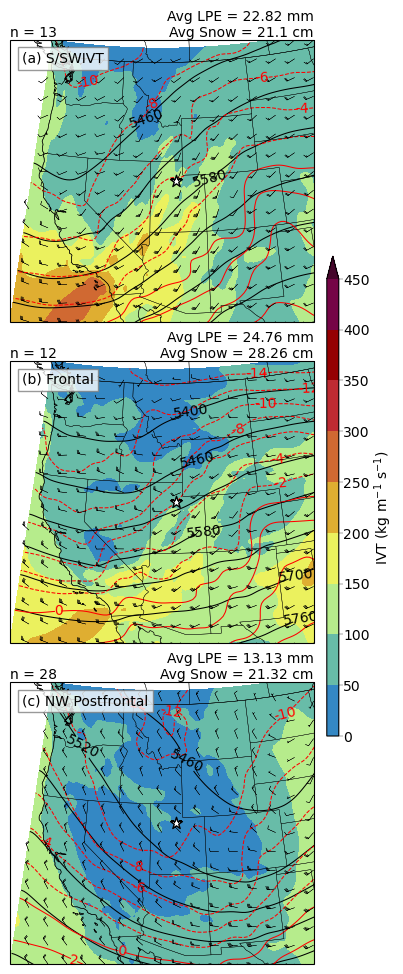

In [ ]:
# Some settings
clevs_ivt     = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450]
clevs_500_hght = np.arange(0, 8000, 60)
clevs_700_t    = np.arange(-48, 48, 2)
regrid_shape   = 16
pad, fs, clabel_fs = 2, 10, 10
props = dict(boxstyle='square', facecolor='white', alpha=0.8, ec='gray')

# For labels
panels = [
    ('(a) S/SWIVT',       data_SW),
    ('(b) Frontal',       data_FR),
    ('(c) NW Postfrontal', data_PF),
]

# Create figure and axes
fig, axes = plt.subplots(3, 1, subplot_kw={'projection': mapcrs}, figsize=(12, 12))

# Loop through axes and extract the data
for ax, (label, d) in zip(axes, panels):
    lons, lats = d['lons'], d['lats']

    ax.set_extent([left_lon, right_lon, bot_lat, top_lat], crs=datacrs)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5,  zorder=100)
    ax.add_feature(cfeature.STATES.with_scale('50m'),   linewidth=0.25, zorder=100)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'),  linewidth=0.25, zorder=100)

    # 500-hPa geopotential height
    cs = ax.contour(lons, lats, d['hght_500'].mean(axis=0), clevs_500_hght,
                    colors='black', linewidths=0.75,
                    transform=datacrs, transform_first=True)
    ax.clabel(cs, fmt='%d', fontsize=clabel_fs)

    # 700-hPa temperature
    cs = ax.contour(lons, lats, d['t_700'].mean(axis=0), clevs_700_t,
                    colors='red', linewidths=0.75,
                    transform=datacrs, transform_first=True)
    ax.clabel(cs, cs.levels, fmt='%d', fontsize=clabel_fs)

    # 700-hPa wind barbs
    ax.barbs(lons, lats, d['u_700'].mean(axis=0), d['v_700'].mean(axis=0),
             transform=datacrs, length=3.5, linewidth=0.25,
             zorder=3, color='black', alpha=1.0, regrid_shape=regrid_shape)

    # IVT filled contours
    cf = ax.contourf(lons, lats, d['IVT'].mean(axis=0), clevs_ivt,
                     colors=ivt_fill_colors(), extend='max',
                     transform=datacrs, transform_first=True)

    n = d['u_700'].shape[0]
    ax.set_title(f'n = {n}', loc='left', pad=pad, fontsize=fs)
    ax.set_title(f"Avg LPE = {d['mean_LPE']} mm\nAvg Snow = {d['mean_snow']} cm",
                 loc='right', pad=pad, fontsize=fs)

    # Panel label
    ax.text(0.04, 0.92, label, transform=ax.transAxes,
            bbox=props, zorder=130, fontsize=fs)

    # Alta marker
    ax.scatter(alta_lon, alta_lat, zorder=200, color='white', s=80,
               edgecolor='black', marker='*', transform=ccrs.PlateCarree())

fig.subplots_adjust(hspace=0.14, wspace=0.05)

# IVT colorbar
cbar_ax = fig.add_axes([0.65, 0.3, 0.01, 0.4])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='vertical',
                    pad=0.01, aspect=40, extend='max', shrink=0.5)
cbar.ax.tick_params(length=2, width=0.25, pad=0.01, size=3, labelsize=fs)
cbar.set_label('IVT (kg m$^{-1}$ s$^{-1}$)', labelpad=2, fontsize=fs)

# Save figure
plt.savefig('Fig/IVT_composite_3_Panel_v2_sampled.png', bbox_inches='tight', dpi=255, facecolor='white')
plt.show()
